## Import Libraries

We import the necessary libraries for:
- Image processing (OpenCV)
- Feature extraction (HOG)
- Machine learning (scikit-learn)
- Data handling (NumPy)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from pathlib import Path
from skimage.color import rgb2gray


# Global seed
RANDOM_STATE = 1996

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Dataset Overview

The dataset consists of Pokémon images grouped by class, with each class corresponding to a unique Pokémon label. In the 5-augmentation dataset used for this experiment, there are 151 classes. The data was split into training, validation, and test sets containing 21,744; 1,208; and 1,208 images. The training set is balanced, with 144 images per class.

In [ ]:
IMAGE_SIZE = (64, 64)

DATA_PATH = Path.home() / "Library" / "CloudStorage" / "GoogleDrive-jesstwentworth@gmail.com" / "My Drive" / "Machine Learning Group Project"

AUG_VERSION = "5aug"


X_train = np.load(DATA_PATH / f"X_train_{AUG_VERSION}.npy")
X_val   = np.load(DATA_PATH / f"X_val_{AUG_VERSION}.npy")
X_test  = np.load(DATA_PATH / f"X_test_{AUG_VERSION}.npy")

y_train = np.load(DATA_PATH / f"y_train_{AUG_VERSION}.npy")
y_val   = np.load(DATA_PATH / f"y_val_{AUG_VERSION}.npy")
y_test  = np.load(DATA_PATH / f"y_test_{AUG_VERSION}.npy")

# Sanity check
print(f"\nDataset Loaded: {AUG_VERSION}")
print("-" * 40)
print("Train shape:", X_train.shape, "|", y_train.shape)
print("Val shape:  ", X_val.shape,   "|", y_val.shape)
print("Test shape: ", X_test.shape,  "|", y_test.shape)

print("\nData type:", X_train.dtype)
print("Pixel range:", X_train.min(), "to", X_train.max())

print("\nNumber of classes:", len(np.unique(y_train)))


Dataset Loaded: 5aug
----------------------------------------
Train shape: (21744, 12288) | (21744,)
Val shape:   (1208, 12288) | (1208,)
Test shape:  (1208, 12288) | (1208,)

Data type: float32
Pixel range: 0.0 to 1.0

Number of classes: 151


## Data Distribution

We verify that each class contains a similar number of images to ensure a balanced dataset.

In [38]:
total_images = 0

# get unique class names (like folder names before)
class_names = np.unique(y_train)

for class_name in class_names:
    
    # count how many images belong to this class
    num_images = np.sum(y_train == class_name)
    
    total_images += num_images
    
    print(f"{class_name}: {num_images}")

print("Total images:", total_images)

abra: 144
aerodactyl: 144
alakazam: 144
arbok: 144
arcanine: 144
articuno: 144
beedrill: 144
bellsprout: 144
blastoise: 144
bulbasaur: 144
butterfree: 144
caterpie: 144
chansey: 144
charizard: 144
charmander: 144
charmeleon: 144
clefable: 144
clefairy: 144
cloyster: 144
cubone: 144
dewgong: 144
diglett: 144
ditto: 144
dodrio: 144
doduo: 144
dragonair: 144
dragonite: 144
dratini: 144
drowzee: 144
dugtrio: 144
eevee: 144
ekans: 144
electabuzz: 144
electrode: 144
exeggcute: 144
exeggutor: 144
farfetch'd: 144
fearow: 144
flareon: 144
gastly: 144
gengar: 144
geodude: 144
gloom: 144
golbat: 144
goldeen: 144
golduck: 144
golem: 144
graveler: 144
grimer: 144
growlithe: 144
gyarados: 144
haunter: 144
hitmonchan: 144
hitmonlee: 144
horsea: 144
hypno: 144
ivysaur: 144
jigglypuff: 144
jolteon: 144
jynx: 144
kabuto: 144
kabutops: 144
kadabra: 144
kakuna: 144
kangaskhan: 144
kingler: 144
koffing: 144
krabby: 144
lapras: 144
lickitung: 144
machamp: 144
machoke: 144
machop: 144
magikarp: 144
magmar: 1

Each class contains an equal number of observations (144), confirming that the dataset is fully balanced. This consistency ensures that the model is not biased toward any particular class and that performance metrics such as accuracy provide a reliable measure of generalization across all categories.

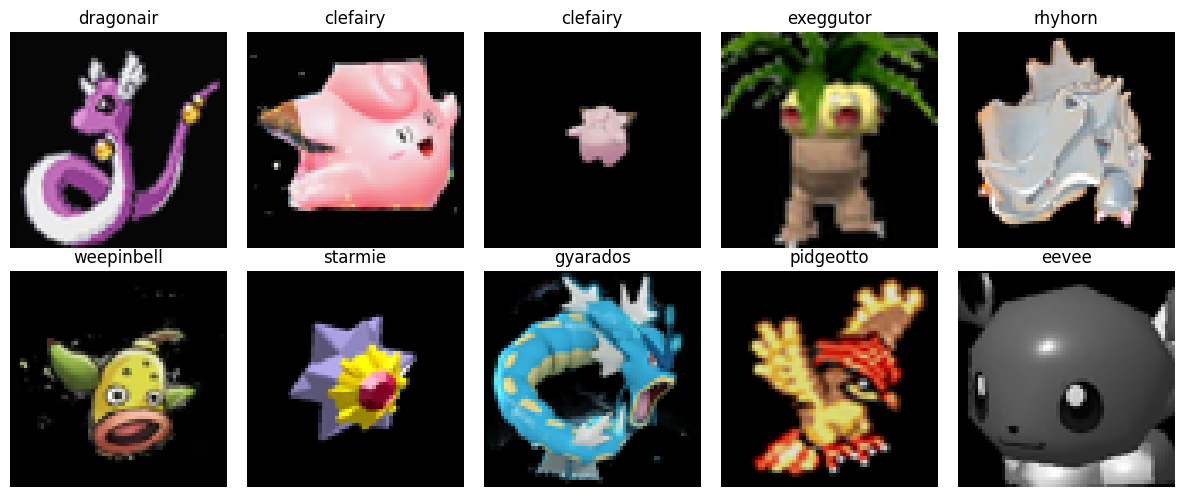

In [47]:
rng = np.random.default_rng(RANDOM_STATE)
indices = rng.choice(len(X_train), 10, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    img = X_train[idx].reshape(64, 64, 3)
    plt.imshow(img)
    plt.title(y_train[idx])
    plt.axis("off")

plt.tight_layout()
plt.show()

Sample images were visualized after reconstructing flattened pixel arrays into their original 64×64×3 format. The visual inspection confirmed that images were correctly processed, labeled, and preserved after augmentation and flattening. 

In [48]:
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())
print("Mean pixel value:", X_train.mean())

Min pixel value: 0.0
Max pixel value: 1.0
Mean pixel value: 0.1862858


* 0 = black and 1 = full intensity
* a mean of  0.186 indicate that images are mostly dark

Pixel intensity analysis showed that all images were normalized to a range between 0 and 1. The mean pixel intensity of approximately 0.186 indicates that images are predominantly dark, which is expected due to the use of black backgrounds and centered subjects. 

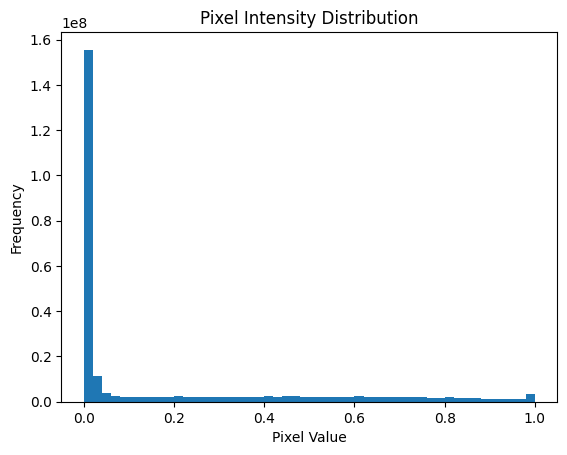

In [27]:
plt.hist(X_train.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

Distribution graph:
- A strong concentration of values near zero 
- Large proportion of the dataset consists of dark pixels. most likely due to the use of black backgrounds during preprocessing
- Higher intensity values occupy a smaller portion of each image.  
 
 Overall
 - eda confirmed that the dataset is well-structured and suitable for modeling. 
 - Images were successfully reconstructed from flattened arrays into their original 64×64×3 format
 - visual inspection verified correct labeling and preprocessing.
 - Pixel values were normalized between 0 and 1, with a mean intensity of approximately 0.186, reflecting the dark background and centered subject design
 - class distribution was perfectly balanced, ensuring unbiased model training.

In [ ]:
# data leakage
train_hashes = set(map(tuple, X_train.reshape(len(X_train), -1)))
val_hashes   = set(map(tuple, X_val.reshape(len(X_val), -1)))

overlap = train_hashes.intersection(val_hashes)
print("Overlap between train and val:", len(overlap))

Overlap between train and val: 2


A small overlap of 2 images was detected between the training and validation sets. Given the dataset size (over 21,000 training samples), this represents a negligible proportion and is unlikely to significantly impact model evaluation. 

## Feature Extraction using HOG

Histogram of Oriented Gradients (HOG) is used to extract edge and texture information from images. This transforms each image into a feature vector.

In [ ]:
def extract_hog_features(image_flat):
    image = image_flat.reshape(64, 64, 3)
    image_gray = rgb2gray(image)

    hog_features = hog(
        image_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False
    )
    return hog_features

In [ ]:
X_train_hog = np.array([extract_hog_features(img) for img in X_train])
X_val_hog   = np.array([extract_hog_features(img) for img in X_val])
X_test_hog  = np.array([extract_hog_features(img) for img in X_test])

print("HOG train shape:", X_train_hog.shape)
print("HOG val shape:", X_val_hog.shape)
print("HOG test shape:", X_test_hog.shape)

HOG train shape: (21744, 1764)
HOG val shape: (1208, 1764)
HOG test shape: (1208, 1764)


HOG feature extraction reduced each image from 12,288 raw pixel features to 1,764 engineered features while preserving edge and shape information. This dimensionality reduction makes the feature space more compact and interpretable, which is beneficial for a baseline Random Forest classifier.

## Generate Feature Matrix

We convert all images into feature vectors and corresponding labels.

In [52]:
print("Train feature matrix shape:", X_train_hog.shape)
print("Train label vector shape:", y_train.shape)

print("\nValidation feature matrix shape:", X_val_hog.shape)
print("Validation label vector shape:", y_val.shape)

print("\nTest feature matrix shape:", X_test_hog.shape)
print("Test label vector shape:", y_test.shape)

Train feature matrix shape: (21744, 1764)
Train label vector shape: (21744,)

Validation feature matrix shape: (1208, 1764)
Validation label vector shape: (1208,)

Test feature matrix shape: (1208, 1764)
Test label vector shape: (1208,)


### Feature Matrix Overview

The dataset was transformed into a feature matrix using Histogram of Oriented Gradients (HOG) feature extraction.
- Number of samples (training): 21,744 images
- Number of samples (validation): 1,208 images
- Number of samples (test): 1,208 images
- Number of features per image: 1,764
- Each row represents one image
- Each column represents a HOG-derived feature

The dimensionality of each image was reduced as follows:
- Raw image: 64 × 64 × 3 = 12,288 pixel values
- Grayscale conversion: 64 × 64 = 4,096 values
- HOG feature extraction: 1,764 features

### Image Preprocessing

All images were resized to a fixed dimension of 64 × 64 pixels to ensure consistency across the dataset. Although the original images contain three color channels (RGB), they were converted to grayscale prior to feature extraction. This step simplifies the data representation and reduces computational complexity while preserving essential structural information.

The grayscale images were then transformed into feature vectors using the Histogram of Oriented Gradients (HOG) method. HOG captures edge directions and gradient patterns, which are particularly effective for representing object shapes. This process reduced the input from 12,288 raw pixel values to a more compact and informative representation of 1,764 features per image.

## Random Forest Model Training

A Random Forest classifier was trained using the extracted HOG feature vectors.

The model was configured with:
- 100 decision trees (n_estimators = 100)
- A fixed random seed (random_state = 1996) to ensure reproducibility
- Parallel processing (n_jobs = -1) to improve training efficiency

In [63]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_classifier.fit(X_train_hog, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Model Evaluation

We evaluate the model using:
- Accuracy
- Classification report (precision, recall, F1-score)
- Confusion matrix

In [54]:
# Validation
y_val_pred = rf_classifier.predict(X_val_hog)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_accuracy:.2%}")
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

# Test
y_test_pred = rf_classifier.predict(X_test_hog)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTest Accuracy: {test_accuracy:.2%}")
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

Validation Accuracy: 24.67%

Validation Classification Report:
              precision    recall  f1-score   support

        abra       0.20      0.25      0.22         8
  aerodactyl       0.00      0.00      0.00         8
    alakazam       0.20      0.38      0.26         8
       arbok       0.12      0.12      0.12         8
    arcanine       0.00      0.00      0.00         8
    articuno       0.27      0.38      0.32         8
    beedrill       0.23      0.38      0.29         8
  bellsprout       0.22      0.25      0.24         8
   blastoise       0.00      0.00      0.00         8
   bulbasaur       0.10      0.12      0.11         8
  butterfree       0.21      0.38      0.27         8
    caterpie       0.00      0.00      0.00         8
     chansey       0.32      0.75      0.44         8
   charizard       0.00      0.00      0.00         8
  charmander       0.33      0.25      0.29         8
  charmeleon       0.17      0.12      0.14         8
    clefable      

/Users/jessicawentworth/Documents/ML Group Project/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jessicawentworth/Documents/ML Group Project/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jessicawentworth/Documents/ML Group Project/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedM

### Results and Evaluation

#### Results:
- Validation Accuracy: 24.67%
- Test Accuracy: 24.01%

With 151 Pokémon classes, random guessing would achieve 0.66% (1/151) accuracy. The Random Forest model achieved approx 24% accuracy, which is significantly higher than random baseline performance, this shows that the model has learned meaningful patterns from the data.

Stronger classes
Some Pokémon were classified more successfully, likely because they have more distinctive shapes or silhouettes:
- Staryu → 0.67 F1
- Muk → 0.67 F1
- Diglett → 0.60 F1
- Geodude → 0.60 F1
- Exeggutor → 0.59 F1

Weaker classes
Other Pokémon had very low or zero performance, suggesting the model struggled to distinguish them from visually similar classes:
- Pikachu → 0.00 F1
- Charizard → 0.00 F1
- Charmander → 0.00 F1
- Squirtle → 0.00 F1
- Persian → 0.00 F1


#### Summary

The Random Forest baseline model using HOG features achieved a validation accuracy of 24.67% and a test accuracy of 24.01% on a 151-class Pokémon classification task. Since random guessing would yield only about 0.66% accuracy, the model performs substantially better than chance and demonstrates that HOG features provide useful structural information for classification.

Performance varied considerably across classes. Some Pokémon, such as Staryu, Muk, and Diglett, achieved relatively strong F1-scores, suggesting that the model was better able to recognize classes with distinctive shapes and edge patterns. In contrast, several classes, including Pikachu, Charizard, and Squirtle, had very low or zero F1-scores, indicating that the model struggled with visually similar or less distinctive classes.

The close agreement between validation and test accuracy suggests that the model generalizes consistently and does not appear to suffer from substantial overfitting. However, overall performance remains limited by the use of handcrafted features and a traditional machine learning classifier. While HOG captures edge and gradient information effectively, it cannot fully represent the complex spatial patterns and fine-grained visual differences needed for high-accuracy Pokémon classification.

This Random Forest model serves as a meaningful baseline for comparison with more advanced approaches, such as Convolutional Neural Networks (CNNs), which are expected to perform better by learning hierarchical image features directly from the data.

## Confusion Matrix

The confusion matrix provides a detailed view of model performance by showing how predictions are distributed across all classes.

It highlights which Pokémon are commonly misclassified, offering insight into patterns of confusion between visually similar classes.

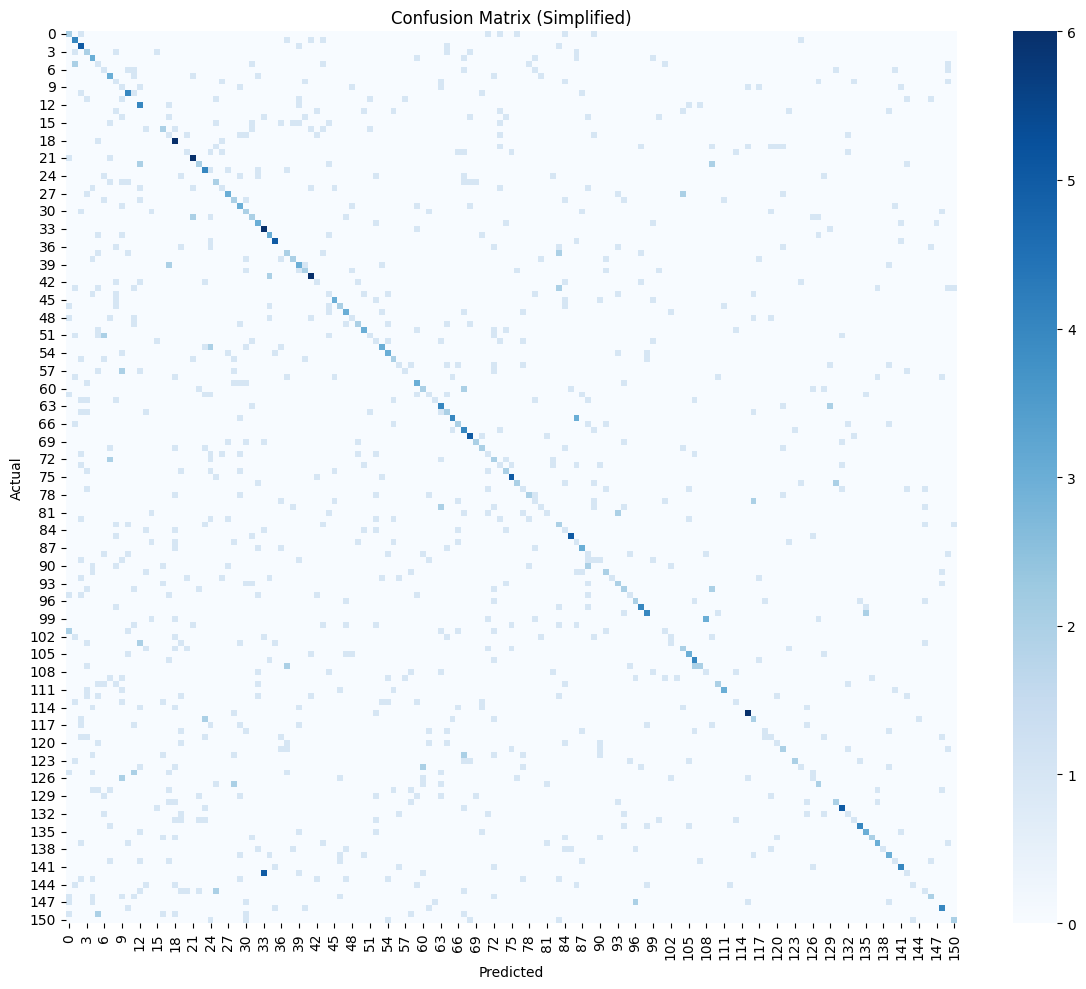

In [62]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    cmap="Blues",
    cbar=True
)

plt.title("Confusion Matrix (Simplified)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Results:
Strong Class Performance
Several Pokémon classes achieved higher correct classification counts, particularly those with more distinctive shapes and edge structures. Examples include:
- Staryu → strong diagonal presence
- Muk → high number of correct predictions
- Diglett → consistently recognized
- Geodude → strong shape-based recognition
- Exeggutor → high classification accuracy

Major Confusion Areas
Evolutionary Line Confusion
- Pokémon within the same evolution chains are frequently misclassified as one another
- Examples include:
- Charmander → Charmeleon → Charizard
- Bulbasaur → Ivysaur → Venusaur

The model struggles with fine-grained differences within evolution chains where shapes and features are very similar

Visually Similar Pokémon Confusion
- Pokémon with similar silhouettes or body structures are often confused
- Examples include:
- Bird Pokémon (e.g., Pidgey, Pidgeotto, Pidgeot)
- Small or round-bodied Pokémon (e.g., Clefairy, Jigglypuff)
- Aquatic or serpentine shapes (e.g., Dratini, Dragonair)

Low Recognition Classes
- Several classes received few or zero correct predictions
- Examples include:
- Pikachu
- Charizard
- Squirtle
- Persian

These classes are either:
- visually similar to others, or
- not well represented by HOG edge-based features


### Confusion Matrix Analysis

The confusion matrix reveals important patterns in model performance across all 151 Pokémon classes.

A visible but relatively weak diagonal is present, indicating that the model correctly classifies some Pokémon but struggles with overall class separation. While certain classes with distinctive shapes (e.g., Staryu, Muk, Geodude) show stronger diagonal values, a large number of off-diagonal entries indicate frequent misclassifications.

Significant confusion is observed among Pokémon within the same evolutionary lines. For example, Charmander, Charmeleon, and Charizard are often misclassified as one another. Similar patterns appear across multiple evolution chains and groups of visually similar Pokémon.

These patterns suggest that while HOG features effectively capture general shape and edge information, they are not sufficient for distinguishing subtle visual differences between closely related classes. The model relies heavily on coarse structural features, leading to confusion when classes share similar outlines or textures.

Overall, the confusion matrix highlights the limitations of traditional feature engineering and machine learning approaches for large-scale image classification tasks. This reinforces the need for more advanced models, such as Convolutional Neural Networks (CNNs), which can learn hierarchical and fine-grained visual representations directly from raw image data.